In [69]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load historical loan default data 
df = pd.read_csv('loan_defaults.csv')
print('Dataset shape:', df.shape)
print()
df.head()

Dataset shape: (150, 4)



,income,debt_ratio,num_late_payments,defaulted
0,877933,0.25,3,0
1,292175,0.20,1,0
2,346524,0.43,8,1
3,289362,0.17,10,1
4,42544,0.73,0,1


In [70]:
# Seperate features (X) from the label (y)
# Features = what we know about the defaulters
# Label = the outcome we want to predict

X = df[['income', 'debt_ratio', 'num_late_payments']]
y = df['defaulted']

print('Features (X) - 4 columns, 150 rows:')
print(X.head(4))
print()
print('Label (y) - What we want to Predict:')
print(y.values)
print(f'APPROVED : {y.sum()} | REJECTED : {(y==0).sum()}')

Features (X) - 4 columns, 150 rows:
   income  debt_ratio  num_late_payments
0  877933        0.25                  3
1  292175        0.20                  1
2  346524        0.43                  8
3  289362        0.17                 10

Label (y) - What we want to Predict:
[0 0 1 1 1 0 0 1 0 1 0 1 1 1 1 1 1 1 1 0 0 0 1 1 0 1 0 0 0 1 1 0 1 1 0 1 0
 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 0 1 1 1
 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1 1 0
 1 1 1 1 1 0 0 0 1 1 0 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 0
 1 1]
APPROVED : 104 | REJECTED : 46


In [71]:
# Split: 95% for training, 5% for testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.05, random_state=42
)

print(f'TRAINING SET : {len(X_train)} DEFULTERS')
print(f'TEST SET : {len(X_train)} DEFULTERS')
print()

# Train the ML MODEL - It learns the rules from Training Data
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)                       # <-- this is where learning happens

print('MODEL TRAINED. It has now seen', len(X_train), "Examples..")
print('It Learned Patterns - No Rules were Written by Hand..')

TRAINING SET : 142 DEFULTERS
TEST SET : 142 DEFULTERS

MODEL TRAINED. It has now seen 142 Examples..
It Learned Patterns - No Rules were Written by Hand..


In [72]:
# Evaluate on test set - applicants the model has NEVER seen
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print('Test set predictions vs actual decisions:')
print(f'{"Actual":<20} {"ML Predicted":<25} {"Match?"}')
print('-' * 35)
for actual, predicted in zip(y_test, y_pred):
    match = 'YES' if actual == predicted else 'NO'
    label_a = 'APPROVED' if actual    else 'REJECTED'
    label_p = 'APPROVED' if predicted else 'REJECTED'
    print(f'{label_a:<20} {label_p:<25} {match}')

print()
print(f'Accuracy: {accuracy*100:.0f}%')

Test set predictions vs actual decisions:
Actual               ML Predicted              Match?
-----------------------------------
APPROVED             APPROVED                  YES
APPROVED             APPROVED                  YES
REJECTED             APPROVED                  NO
REJECTED             REJECTED                  YES
APPROVED             APPROVED                  YES
REJECTED             REJECTED                  YES
REJECTED             REJECTED                  YES
APPROVED             APPROVED                  YES

Accuracy: 88%


In [73]:
print('SUPERVISED LEARNING - Loan Prediction Results:')
print('TEST ACCURACY :', round(accuracy * 100), '%')
print()
print('PREDICTIONS Vs ACTUAL:')

# Turn y_test into a normal list so we can count through it with a number
actual_list = list(y_test)

# Go through each customer one at a time, using a simple counter (i)
for i in range(len(actual_list)):
    actual_value = actual_list[i]
    predicted_value = y_pred[i]

    if actual_value == 0:
        actual_test = 'REJECTED'
    else:
        actual_test = 'APPROVED'

    if predicted_value == 1:
        predicted_test = 'APPROVED'
    else:
        predicted_test = 'REJECTED'

    if actual_value == predicted_value:
        result = 'CORRECT'
    else:
        result = 'WRONG'

    print('Customer', i + 1, '-> Actual:', actual_test, '| Predicted:', predicted_test, '| Model was', result)

SUPERVISED LEARNING - Loan Prediction Results:
TEST ACCURACY : 88 %

PREDICTIONS Vs ACTUAL:
Customer 1 -> Actual: APPROVED | Predicted: APPROVED | Model was CORRECT
Customer 2 -> Actual: APPROVED | Predicted: APPROVED | Model was CORRECT
Customer 3 -> Actual: REJECTED | Predicted: APPROVED | Model was WRONG
Customer 4 -> Actual: REJECTED | Predicted: REJECTED | Model was CORRECT
Customer 5 -> Actual: APPROVED | Predicted: APPROVED | Model was CORRECT
Customer 6 -> Actual: REJECTED | Predicted: REJECTED | Model was CORRECT
Customer 7 -> Actual: REJECTED | Predicted: REJECTED | Model was CORRECT
Customer 8 -> Actual: APPROVED | Predicted: APPROVED | Model was CORRECT


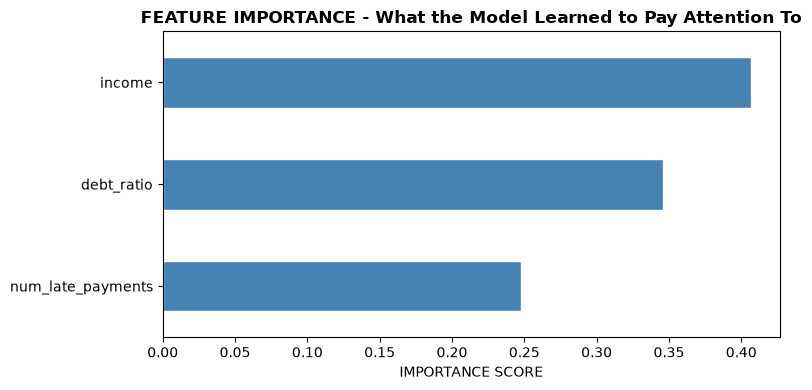

The model assigned importance to each feature based on the training data.
This is the pattern it learned - no human specified these weights.


In [74]:
import matplotlib.pyplot as plt

# Feature importance - which feature mattered most to the model?
importance = pd.Series(
    model.feature_importances_,
    index=['income', 'debt_ratio', 'num_late_payments']
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importance.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('FEATURE IMPORTANCE - What the Model Learned to Pay Attention To',
             fontsize=12, fontweight='bold')
ax.set_xlabel('IMPORTANCE SCORE')
plt.tight_layout()
plt.show()

print('The model assigned importance to each feature based on the training data.')
print('This is the pattern it learned - no human specified these weights.')